# Setup — data for the session

**Run this notebook once, before the session.**

It downloads the dataset (~1.1 GB, peaks at ~3 GB RAM), subsets it to a single brain
section, applies basic QC and normalisation, and writes the result to
`data/brain_section.h5ad`. Notebooks 01–03 each load that file in a couple of seconds.

The data come from [*A molecularly defined and spatially resolved cell atlas of the whole
mouse brain* (Nature, 2023)](https://www.nature.com/articles/s41586-023-06808-9);
[WB_MERFISH_animal2_coronal](https://cellxgene.cziscience.com/collections/0cca8620-8dee-45d0-aef5-23f032a5cf09).
The dataset was generated using **MERFISH**, which enables highly multiplexed
single-molecule RNA imaging with subcellular spatial resolution. It profiles more than
**1,000** genes across roughly **10 million cells** in the adult **mouse brain**.

In [1]:
import scanpy as sc

import liana as li

# cache the download under ../../data (repo root) rather than the current working directory
sc.settings.datasetdir = "../../data"
sc.set_figure_params(ipython_format='jpeg')

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## Download and subset

The full object is ~1.9 M cells. We work with a single coronal section throughout.

In [2]:
adata = li.ds.yao_2023()

# Subset to one brain section
adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
# The dataset indexes vars by Ensembl ID; switch to gene symbols for LR lookup
adata.var_names = adata.var["gene_name"]

adata = adata.copy()
print(adata)

AnnData object with n_obs × n_vars = 51545 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layers: None (.X)


## QC and normalisation

Raw counts are kept in a layer; all methods below use normalised log1p values.

In [3]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)

adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print(adata.shape)

(51539, 1120)


Spatial coordinates are in **µm** (MERFISH physical units), stored in `adata.obsm['X_spatial_coords']`.

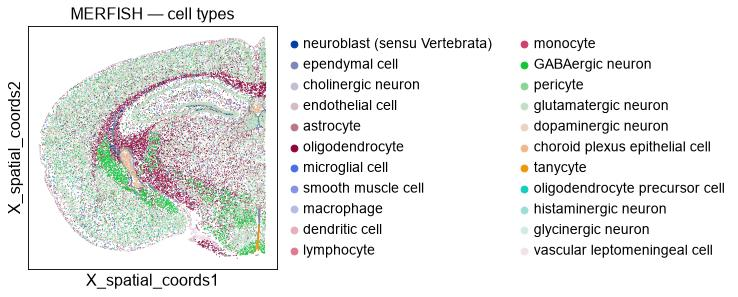

In [4]:
sc.pl.embedding(
    adata, basis="X_spatial_coords",
    color="cell_type", s=3, title="MERFISH — cell types"
)

## Ligand–receptor resource

LIANA+ ships a mouse-specific consensus resource, so no ortholog conversion is needed
here. (For organisms without a ready-made resource, `li.rs.get_hcop_orthologs` +
`li.rs.translate_resource` map the human `consensus` resource across.)

In [5]:
resource = li.rs.select_resource('mouseconsensus')
print(f"{len(resource)} LR pairs in resource")
resource.head(5)

3989 LR pairs in resource


,ligand,receptor
31367,Dll1,Notch1
31368,Dll1,Notch2
31369,Dll1,Notch4
31370,Dll1,Notch3
31371,Nrg2,Erbb2_Erbb3


## Save

Everything downstream starts from this file.

In [6]:
adata.write_h5ad("../../data/brain_section.h5ad")
print("wrote ../../data/brain_section.h5ad")

wrote ../../data/brain_section.h5ad


---

You are set up. In the session we will work through:

1. `01_restricting_lr_methods.ipynb` — which cell types talk to which, if they are close enough to?
2. `02_spatial_scales.ipynb` — at what distance does an interaction happen?
3. `03_local_hotspots.ipynb` — where in the tissue does it happen?